# Tarification automobile — Assemblage fréquence × gravité

**Résultat attendu : une prime pure par prospect et un fichier `submission.csv` (`index,pred`).**

Nous réunissons les modèles retenus dans les deux notebooks de l'équipe :

- **Fréquence** : régression logistique, `C = 0.1`, issue de `frequence_regression_logisitique.ipynb`.
- **Gravité** : régression Gamma à lien logarithmique, `alpha = 0.1`, avec `type_contrat`, `anciennete_vehicule`, `utilisation`, issue de `modele_gravite.ipynb`.

Les notebooks individuels conservent l'analyse exploratoire et la sélection des modèles. Celui-ci contient **tout le code nécessaire pour réentraîner et assembler les deux modèles**, sans exécuter ces notebooks et sans utiliser leurs variables en mémoire. Les deux fichiers `Data/train.csv` et `Data/test.csv` suffisent.

Plan : contrôler les données → partager une partition par client → préparer la fréquence → reconstruire Gamma → mesurer la prime en validation → réentraîner sur toutes les données autorisées → exporter et vérifier le résultat.

## 1. Ce que nous prédisons et ce que nous mesurons

Soit $S$ le coût observé : zéro sans sinistre et le montant du sinistre sinon. Pour les données actuelles, `nombre_sinistres` vaut seulement 0 ou 1.

$$\widehat{p}(x)=\widehat{P}(S>0\mid X=x),\qquad
\widehat{g}(x)=\widehat{E}[S\mid S>0,X=x],\qquad
\widehat{\pi}(x)=\widehat{p}(x)\times\widehat{g}(x).$$

La fréquence apprend sur **tous les contrats d'apprentissage**. La gravité apprend seulement sur **les sinistrés d'apprentissage**, mais prédit un montant conditionnel pour **chaque prospect** : nous ignorons qui aura un accident. Nous multiplions les probabilités directement, sans seuil de classification. Par exemple, 6 % × 1 800 € = 108 € de prime pure.

Le coût cible est observé après la période assurée ; il n'est jamais fourni comme prédicteur. Cette prime ne comprend ni marge commerciale, ni frais, ni taxes.

Le texte de la compétition cite à la fois MSE et RMSE, puis fournit la formule de la **RMSE**. Nous calculons les deux : $\mathrm{MSE}=\mathrm{moyenne}((\widehat\pi-S)^2)$ et $\mathrm{RMSE}=\sqrt{\mathrm{MSE}}$. Ils classent les modèles dans le même ordre ; la RMSE s'exprime en euros. La mesure porte sur **tous les contrats de validation**, y compris les non-sinistrés. Le test Kaggle n'a pas de cible : aucun score local ne peut y être calculé.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
from pathlib import Path
import sys, json, hashlib, subprocess, platform, warnings
import cloudpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression, GammaRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (root_mean_squared_error, mean_squared_error,
    mean_absolute_error, log_loss, brier_score_loss, roc_auc_score)
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)
# Un modèle qui ne converge pas doit être corrigé avant d'exporter.
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

racines = [Path.cwd(), Path.cwd() / 'TD-Tarification-automobile-par-Machine-Learning']
ROOT = next((p for p in racines if (p / 'Data/train.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Ouvrir ce notebook depuis le dépôt ou son dossier parent.')
OUTPUT = ROOT / 'output/prime'
OUTPUT.mkdir(parents=True, exist_ok=True)
SEED = 42
train = pd.read_csv(ROOT / 'Data/train.csv', dtype={'code_postal': str})
test = pd.read_csv(ROOT / 'Data/test.csv', dtype={'code_postal': str})
print('Train :', train.shape, '| Test Kaggle :', test.shape)
print('Dossier des résultats :', OUTPUT)

Matplotlib is building the font cache; this may take a moment.


/home/cytech/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Train : (50000, 33) | Test Kaggle : (50000, 28)
Dossier des résultats : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/prime


## 2. Contrôles avant l'assemblage

Nous vérifions les identifiants, les cibles et la présence des caractéristiques communes. `index` sert à relier les prédictions, **jamais à apprendre le risque**. `id_client` sert uniquement à séparer les clients. Les cibles, les identifiants et les deux champs de sexe sont exclus des entrées du modèle de fréquence ; Gamma sélectionne explicitement ses trois prédicteurs.

Les valeurs extrêmes des sinistres sont conservées : les réduire artificiellement changerait l'objectif de coût. Les analyses détaillées restent dans les notebooks individuels.

In [2]:
CIBLES = ['nombre_sinistres', 'montant_sinistre']
EXCLUES = ['index', 'id_client', 'id_vehicule', 'id_contrat',
           *CIBLES, 'sex_conducteur1', 'sex_conducteur2']
VARIABLES_FREQUENCE = [
    'bonus', 'type_contrat', 'duree_contrat', 'anciennete_info',
    'freq_paiement', 'paiement', 'utilisation', 'code_postal', 'conducteur2',
    'age_conducteur1', 'age_conducteur2', 'anciennete_permis1',
    'anciennete_permis2', 'anciennete_vehicule', 'cylindre_vehicule',
    'din_vehicule', 'essence_vehicule', 'marque_vehicule', 'modele_vehicule',
    'debut_vente_vehicule', 'fin_vente_vehicule', 'vitesse_vehicule',
    'type_vehicule', 'prix_vehicule', 'poids_vehicule']
assert not set(VARIABLES_FREQUENCE).intersection(EXCLUES)
for df in [train, test]:
    assert df['index'].notna().all() and df['index'].is_unique
    assert set(VARIABLES_FREQUENCE).issubset(df.columns)
assert set(CIBLES).isdisjoint(test.columns)
assert set(train.nombre_sinistres.unique()) == {0, 1}
assert np.isfinite(train.montant_sinistre).all()
assert ((train.nombre_sinistres == 0) == (train.montant_sinistre == 0)).all()
assert train.loc[train.nombre_sinistres == 1, 'montant_sinistre'].gt(0).all()
assert set(train['index']).isdisjoint(test['index'])
display(pd.DataFrame({
    'contrats': [len(train), len(test)],
    'sinistres_observés': [int(train.nombre_sinistres.sum()), np.nan],
    'taux_sinistres': [train.nombre_sinistres.mean(), np.nan],
    'coût_moyen_par_contrat_EUR': [train.montant_sinistre.mean(), np.nan],
}, index=['train', 'test Kaggle']))

,contrats,sinistres_observés,taux_sinistres,coût_moyen_par_contrat_EUR
train,50000,"2,917.0000",0.0583,103.3693
test Kaggle,50000,NaN,NaN,NaN


## 3. Une validation commune aux deux modèles

Les notebooks individuels n'utilisaient pas les mêmes contrats de validation. Multiplier leurs anciennes prédictions de validation serait incorrect : certaines observations auraient déjà servi à apprendre l'un des modèles.

Nous reprenons ici le découpage **par client** du notebook de gravité : 80 % des clients pour apprendre, 20 % pour le diagnostic. Les deux modèles sont réentraînés uniquement dans l'apprentissage commun ; nous n'utilisons pas le Gamma sauvegardé sur tout le train pour évaluer cette validation.

Les familles de modèles et les hyperparamètres sont **déjà fixés** par les travaux individuels. Nous ne les choisissons pas à partir du RMSE ci-dessous. Cette validation et les données ont déjà été examinées dans le projet : le résultat est un **diagnostic historique d'intégration**, pas une mesure externe indépendante et pas un score Kaggle. Une partie de cette validation figurait aussi dans l'apprentissage initial de fréquence ; le réentraînement empêche la fuite dans les coefficients actuels, sans effacer les choix méthodologiques antérieurs.

In [3]:
positions_dev, positions_val = next(GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=SEED
).split(train, groups=train.id_client))
dev = train.iloc[positions_dev].copy()
valid = train.iloc[positions_val].copy()
assert set(dev.id_client).isdisjoint(valid.id_client)
partition = train[['index', 'id_client']].rename(columns={'index': 'id'}).copy()
partition['partition'] = np.where(train.index.isin(dev.index), 'apprentissage', 'validation')
assert partition.groupby('id_client').partition.nunique().max() == 1
partition.to_csv(OUTPUT / 'partition_clients_commune.csv', index=False)
# Si le fichier de gravité existe, on vérifie la concordance sans le modifier.
ancienne_partition = ROOT / 'output/gravite/partition_clients.csv'
if ancienne_partition.exists():
    historique = pd.read_csv(ancienne_partition)
    pd.testing.assert_frame_equal(partition.reset_index(drop=True), historique)
display(pd.DataFrame([{
    'partition': nom, 'contrats': len(df), 'clients': df.id_client.nunique(),
    'sinistres': int(df.nombre_sinistres.sum()),
    'taux_sinistres': df.nombre_sinistres.mean(),
    'coût_moyen_par_contrat_EUR': df.montant_sinistre.mean()
} for nom, df in [('apprentissage', dev), ('validation', valid)]]).set_index('partition'))

,contrats,clients,sinistres,taux_sinistres,coût_moyen_par_contrat_EUR
partition,,,,,
apprentissage,40013,36628,2352,0.0588,103.7660
validation,9987,9157,565,0.0566,101.7803


## 4. Réutiliser la préparation du modèle de fréquence

Nous conservons la recette du notebook du partenaire :

1. Poids et cylindrée nuls deviennent manquants ; le code géographique est ramené au département par son préfixe à deux caractères, comme dans son modèle. Les données actuelles sont métropolitaines, avec `2A` et `2B` conservés. Cette règle serait à adapter si des départements d'outre-mer étaient ajoutés.
2. Les six variables redondantes choisies par le partenaire sont retirées.
3. Poids, cylindrée et ancienneté du véhicule sont imputés par médiane du modèle de voiture, puis de la marque, puis globale. Toutes ces médianes proviennent de l'apprentissage seulement.
4. `log1p` réduit l'asymétrie du bonus, de la puissance, du poids et de la cylindrée. Il ne transforme pas la cible.
5. Les catégories de faible cardinalité rares (moins de 50 contrats) sont regroupées, puis encodées en indicatrices avec la modalité la plus fréquente comme référence.
6. Marque, modèle et département sont remplacés par un taux de sinistres **lissé** : $(\text{sinistres}+100\times\text{taux moyen})/(\text{effectif}+100)$. Une catégorie inconnue reçoit le taux moyen appris.
7. Les colonnes numériques non binaires sont standardisées avec les moyennes et écarts-types appris sur l'apprentissage.

**Correction d'intégration explicite :** le notebook de fréquence calculait les taux hors pli avec des paquets aléatoires de lignes et un taux moyen global. Ici, les plis sont groupés par client et le taux moyen est calculé **dans les autres plis seulement**. Un client et sa propre réponse ne contribuent donc pas à son encodage d'apprentissage. Les paramètres `C=0.1`, lissage 100 et seuil rare 50 restent fixés ; nous ne relançons pas la sélection. Les chiffres ne doivent donc pas être présentés comme une reproduction exacte de l'ancien score.

Ces taux utilisent la **cible de fréquence**, jamais le montant du dommage. Nous n'introduisons pas d'encodage cible dans le Gamma à trois variables.

In [4]:
REDONDANTES = ['debut_vente_vehicule', 'fin_vente_vehicule', 'anciennete_permis1',
               'age_conducteur2', 'prix_vehicule', 'vitesse_vehicule']
A_IMPUTER = ['poids_vehicule', 'cylindre_vehicule', 'anciennete_vehicule']
QUEUE_LOURDE = ['bonus', 'din_vehicule', 'poids_vehicule', 'cylindre_vehicule']
CAT_FAIBLE = ['type_contrat', 'freq_paiement', 'paiement', 'utilisation',
              'conducteur2', 'essence_vehicule', 'type_vehicule']
CAT_FORTE = ['marque_vehicule', 'modele_vehicule', 'departement']
SEUIL_RARE, LISSAGE, C_FREQUENCE = 50, 100, 0.1

def nettoyer_frequence(frame):
    manque = sorted(set(VARIABLES_FREQUENCE) - set(frame.columns))
    if manque:
        raise ValueError(f'Colonnes de fréquence absentes : {manque}')
    # Sélection explicite : les cibles présentes dans train ne peuvent pas entrer.
    x = frame.loc[:, VARIABLES_FREQUENCE].copy()
    for col in ['poids_vehicule', 'cylindre_vehicule']:
        x[col] = x[col].replace(0, np.nan)
    x['departement'] = x['code_postal'].astype('string').str[:2]
    x = x.drop(columns='code_postal')
    for col in CAT_FAIBLE + CAT_FORTE:
        x[col] = x[col].astype(object).where(x[col].notna(), '__MANQUANT__')
    return x

def taux_lisse(x, y, prior):
    stats = y.groupby(x).agg(['sum', 'count'])
    return (stats['sum'] + LISSAGE * prior) / (stats['count'] + LISSAGE)

def encoder_hors_clients(x, y, groupes):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    encodage = pd.DataFrame(np.nan, index=x.index, columns=CAT_FORTE)
    audit = []
    for k, (a, b) in enumerate(cv.split(x, y, groups=groupes), 1):
        assert set(groupes.iloc[a]).isdisjoint(groupes.iloc[b])
        prior = float(y.iloc[a].mean())
        for col in CAT_FORTE:
            mapping = taux_lisse(x.iloc[a][col], y.iloc[a], prior)
            encodage.loc[x.index[b], col] = x.iloc[b][col].map(mapping).fillna(prior).to_numpy()
        audit.append({'pli': k, 'contrats_apprentissage': len(a),
            'contrats_encodés': len(b), 'clients_communs': 0, 'prior_autres_plis': prior})
    assert np.isfinite(encodage.to_numpy()).all()
    return encodage, pd.DataFrame(audit)

def transformer_frequence(frame, p, encodage=None):
    x = nettoyer_frequence(frame).drop(columns=REDONDANTES)
    for col in A_IMPUTER:
        x[col] = (x[col].fillna(x.modele_vehicule.map(p[f'med_modele_{col}']))
            .fillna(x.marque_vehicule.map(p[f'med_marque_{col}']))
            .fillna(p[f'med_globale_{col}']))
    for col in QUEUE_LOURDE:
        if (x[col] < 0).any():
            raise ValueError(f'Valeur négative incompatible avec log1p : {col}')
        x[col] = np.log1p(x[col])
    for col in CAT_FORTE:
        if encodage is not None:
            assert encodage.index.equals(x.index)
            x[col] = encodage[col]
        else:
            x[col] = x[col].map(p[f'taux_{col}']).fillna(p['taux_moyen'])
    for col in CAT_FAIBLE:
        x[col] = x[col].where(x[col].isin(p[f'frequentes_{col}']), 'Autre')
    x = pd.get_dummies(x, columns=CAT_FAIBLE, dtype=int)
    x = x.drop(columns=[f'{col}_{p[f"reference_{col}"]}' for col in CAT_FAIBLE], errors='ignore')
    if 'colonnes' in p:
        x = x.reindex(columns=p['colonnes'], fill_value=0)
    return x.astype(float)

def standardiser_frequence(x, p):
    x = x.copy()
    cols = p['colonnes_num']
    x[cols] = (x[cols] - p['moyennes']) / p['ecarts_types']
    if not np.isfinite(x.to_numpy()).all():
        raise ValueError('Préparation de fréquence non finie.')
    return x

def apprendre_frequence(frame, y, groupes):
    assert frame.index.is_unique and frame.index.equals(y.index)
    assert frame.index.equals(groupes.index)
    x = nettoyer_frequence(frame)
    p = {'taux_moyen': float(y.mean())}
    for col in A_IMPUTER:
        p[f'med_modele_{col}'] = x.groupby('modele_vehicule')[col].median()
        p[f'med_marque_{col}'] = x.groupby('marque_vehicule')[col].median()
        p[f'med_globale_{col}'] = float(x[col].median())
    for col in CAT_FAIBLE:
        counts = x[col].value_counts()
        p[f'frequentes_{col}'] = counts[counts >= SEUIL_RARE].index
        p[f'reference_{col}'] = counts.index[0]
    for col in CAT_FORTE:
        p[f'taux_{col}'] = taux_lisse(x[col], y, p['taux_moyen'])
    oof, audit = encoder_hors_clients(x, y, groupes)
    z = transformer_frequence(frame, p, encodage=oof)
    p['colonnes'] = z.columns
    p['colonnes_num'] = [col for col in z if z[col].nunique() > 2]
    p['moyennes'] = z[p['colonnes_num']].mean()
    p['ecarts_types'] = z[p['colonnes_num']].std().replace(0, 1)
    return p, standardiser_frequence(z, p), audit

def preparer_frequence(frame, p):
    # Validation / test : aucun y, toutes les statistiques viennent de p.
    return standardiser_frequence(transformer_frequence(frame, p), p)

## 5. Le Gamma retenu, avec sa préparation complète

Gamma prédit $\widehat g(x)=\exp(b_0+\sum_j b_j z_j)$ : ses sorties sont strictement positives. Le montant cible reste en euros pendant l'apprentissage. L'optimisation minimise une déviance Gamma régularisée, et non directement la RMSE ; la configuration avait été choisie en comparant la RMSE dans le notebook de gravité.

La pipeline reproduit la configuration retenue : imputation médiane puis standardisation de `anciennete_vehicule`, imputation et indicatrices de `type_contrat` et `utilisation`, regroupement des catégories de moins de 20 observations, `alpha=0.1`. Seules ces trois variables entrent dans la régression. Son prétraitement est appris uniquement sur les sinistrés de la partition concernée.

In [5]:
CONFIG_GAMMA = {
    'famille': 'GammaRegressor', 'lien': 'log', 'alpha': 0.1,
    'variables': ['type_contrat', 'anciennete_vehicule', 'utilisation'],
    'numeriques': ['anciennete_vehicule'],
    'categorielles': ['type_contrat', 'utilisation'],
    'colonnes_brutes_necessaires': ['anciennete_vehicule', 'type_contrat', 'utilisation'],
    'min_frequency': 20, 'solver': 'lbfgs', 'max_iter': 3000, 'tol': 1e-5,
}
fichier_config_gravite = ROOT / 'output/gravite/configuration_gravite.json'
if fichier_config_gravite.exists():
    source_gamma = json.loads(fichier_config_gravite.read_text())
    for cle, valeur in CONFIG_GAMMA.items():
        assert source_gamma[cle] == valeur, f'Configuration Gamma différente : {cle}'

def nettoyer_gamma(frame, required_columns):
    manque = sorted(set(required_columns) - set(frame.columns))
    if manque:
        raise ValueError(f'Colonnes de gravité absentes : {manque}')
    x = frame.loc[:, required_columns].copy()
    for col in x.select_dtypes(include=['object', 'string']).columns:
        x[col] = x[col].astype(object).where(x[col].notna(), np.nan)
    return x

def construire_gamma():
    c = CONFIG_GAMMA
    return Pipeline([
        ('clean', FunctionTransformer(nettoyer_gamma, validate=False,
            kw_args={'required_columns': c['colonnes_brutes_necessaires']})),
        ('prep', ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
                ('scale', StandardScaler())]), c['numeriques']),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='__MANQUANT__')),
                ('encoder', OneHotEncoder(min_frequency=c['min_frequency'],
                    handle_unknown='infrequent_if_exist', sparse_output=False))]), c['categorielles'])
        ], remainder='drop')),
        ('model', GammaRegressor(alpha=c['alpha'], solver=c['solver'],
            max_iter=c['max_iter'], tol=c['tol']))
    ])

## 6. Apprendre les deux modèles sur la même partition

La régression logistique apprend les coefficients qui transforment une somme pondérée des entrées en probabilité (fonction sigmoïde), avec régularisation `C=0.1`. Nous n'utilisons pas de poids de classes ni de suréchantillonnage : les probabilités doivent refléter la fréquence réelle pour calculer les primes.

L'encodage hors client est utilisé pour ajuster les coefficients de fréquence. La validation reçoit les taux calculés sur l'ensemble du développement uniquement. Le Gamma apprend sur les sinistrés du même développement. Aucun coût ou indicateur de sinistre de validation ne participe à ces ajustements.

In [6]:
params_valid, x_dev, audit_valid = apprendre_frequence(
    dev, dev.nombre_sinistres, dev.id_client)
x_valid = preparer_frequence(valid, params_valid)
frequence_valid = LogisticRegression(C=C_FREQUENCE, max_iter=2000, random_state=SEED)
frequence_valid.fit(x_dev, dev.nombre_sinistres)
sinistres_dev = dev.loc[dev.nombre_sinistres == 1]
gravite_valid = construire_gamma()
gravite_valid.fit(sinistres_dev, sinistres_dev.montant_sinistre)
assert list(x_dev.columns) == list(x_valid.columns)
print('Fréquence :', len(dev), 'contrats ;', x_dev.shape[1], 'colonnes après préparation.')
print('Gravité :', len(sinistres_dev), 'sinistres ; 3 variables brutes.')
display(audit_valid)
audit_valid.to_csv(OUTPUT / 'audit_encodage_validation.csv', index=False)

Fréquence : 40013 contrats ; 26 colonnes après préparation.
Gravité : 2352 sinistres ; 3 variables brutes.


,pli,contrats_apprentissage,contrats_encodés,clients_communs,prior_autres_plis
0,1,32010,8003,0,0.0588
1,2,32010,8003,0,0.0588
2,3,32011,8002,0,0.0588
3,4,32010,8003,0,0.0588
4,5,32011,8002,0,0.0588


## 7. Assembler par identifiant, puis calculer le score

Chaque modèle prédit pour **tous** les contrats de validation. Nous joignons les résultats sur `id`, avec un contrôle d'unicité et de présence des mêmes identifiants. L'ordre des tableaux ne suffit pas à garantir que deux prédictions concernent le même client.

Nous comparons quatre formules sur exactement les mêmes contrats. La prime constante est le coût moyen du développement, y compris les zéros. Les variantes avec une composante constante aident à voir ce que chaque modèle apporte. Ce sont des diagnostics ; nous ne changeons pas la configuration en fonction de ce classement.

In [7]:
def assembler_composantes(frequence, gravite):
    if not {'id', 'proba_pred'}.issubset(frequence.columns):
        raise ValueError('Fréquence : colonnes id,proba_pred attendues.')
    if not {'id', 'montant_pred'}.issubset(gravite.columns):
        raise ValueError('Gravité : colonnes id,montant_pred attendues.')
    for df in [frequence, gravite]:
        if df.id.isna().any() or not df.id.is_unique:
            raise ValueError('Identifiant manquant ou dupliqué.')
    if set(frequence.id) != set(gravite.id):
        raise ValueError('Les identifiants de fréquence et gravité diffèrent.')
    joint = frequence[['id', 'proba_pred']].merge(
        gravite[['id', 'montant_pred']], on='id', how='left', sort=False, validate='one_to_one')
    if not np.isfinite(joint[['proba_pred', 'montant_pred']].to_numpy()).all():
        raise ValueError('Prédiction non finie.')
    if not joint.proba_pred.between(0, 1).all() or not joint.montant_pred.gt(0).all():
        raise ValueError('Probabilité ou montant invalide.')
    joint['pred'] = joint.proba_pred * joint.montant_pred
    return joint

classe_sinistre = int(np.flatnonzero(frequence_valid.classes_ == 1)[0])
p_valid = frequence_valid.predict_proba(x_valid)[:, classe_sinistre]
g_valid = gravite_valid.predict(valid)
details_valid = assembler_composantes(
    pd.DataFrame({'id': valid['index'].to_numpy(), 'proba_pred': p_valid}),
    pd.DataFrame({'id': valid['index'].to_numpy(), 'montant_pred': g_valid}))
reference = valid[['index', 'nombre_sinistres', 'montant_sinistre']].rename(
    columns={'index': 'id', 'montant_sinistre': 'cout_reel'})
details_valid = details_valid.merge(reference, on='id', validate='one_to_one', sort=False)
assert np.array_equal(details_valid.id, valid['index'])
cout_reel = details_valid.cout_reel.to_numpy()
taux_dev = dev.nombre_sinistres.mean()
gravite_moyenne_dev = sinistres_dev.montant_sinistre.mean()
prime_moyenne_dev = dev.montant_sinistre.mean()
np.testing.assert_allclose(prime_moyenne_dev, taux_dev * gravite_moyenne_dev)

def scores_prime(observe, prediction):
    return {'RMSE_EUR': root_mean_squared_error(observe, prediction),
            'MSE_EUR2': mean_squared_error(observe, prediction),
            'MAE_EUR': mean_absolute_error(observe, prediction),
            'biais_moyen_EUR': float(np.mean(prediction - observe)),
            'ratio_cout_predit_observe': float(np.sum(prediction) / np.sum(observe))}

variantes = {
    'Prime_constante': np.full(len(valid), prime_moyenne_dev),
    'Logistique_x_gravite_moyenne': p_valid * gravite_moyenne_dev,
    'Frequence_moyenne_x_Gamma': taux_dev * g_valid,
    'Logistique_x_Gamma': details_valid.pred.to_numpy(),
}
scores = pd.DataFrame({nom: scores_prime(cout_reel, prediction)
    for nom, prediction in variantes.items()}).T
scores['gain_RMSE_vs_constante_pct'] = 100 * (
    1 - scores.RMSE_EUR / scores.loc['Prime_constante', 'RMSE_EUR'])
display(scores)
scores.to_csv(OUTPUT / 'scores_validation_prime.csv', index_label='formule')
details_valid.to_csv(OUTPUT / 'predictions_prime_validation.csv', index=False)
display(details_valid.head())

,RMSE_EUR,MSE_EUR2,MAE_EUR,biais_moyen_EUR,ratio_cout_predit_observe,gain_RMSE_vs_constante_pct
Prime_constante,511.4665,"261,597.9762",193.8055,1.9856,1.0195,0.0000
Logistique_x_gravite_moyenne,507.7960,"257,856.8109",190.9911,2.7930,1.0274,0.7176
Frequence_moyenne_x_Gamma,510.2529,"260,358.0001",188.0814,-3.6783,0.9639,0.2373
Logistique_x_Gamma,507.6470,"257,705.4938",190.3774,2.6928,1.0265,0.7468


,id,proba_pred,montant_pred,pred,nombre_sinistres,cout_reel
0,1,0.1125,"1,793.3575",201.7037,0,0.0000
1,4,0.0607,"1,594.9826",96.8365,0,0.0000
2,7,0.0548,"1,594.9826",87.4566,0,0.0000
3,11,0.0719,"1,763.5748",126.7801,0,0.0000
4,13,0.0526,"1,542.4460",81.1403,0,0.0000


### Comprendre les performances de chaque composante

Pour la fréquence, log-loss et Brier mesurent la qualité des probabilités ; AUC mesure leur classement. Pour la gravité, RMSE et MAE sont calculées **uniquement sur les sinistrés de validation**. Ces deux diagnostics ne remplacent pas le RMSE de la prime sur tout le portefeuille. Un bon classement des risques ne suffit pas si les probabilités sont mal calibrées ou si les montants sont biaisés.

In [8]:
sinistres_valid = details_valid.nombre_sinistres.eq(1)
score_frequence = pd.DataFrame([{
    'log_loss': log_loss(details_valid.nombre_sinistres, details_valid.proba_pred),
    'Brier': brier_score_loss(details_valid.nombre_sinistres, details_valid.proba_pred),
    'AUC': roc_auc_score(details_valid.nombre_sinistres, details_valid.proba_pred),
    'sinistres_predits': details_valid.proba_pred.sum(),
    'sinistres_observes': details_valid.nombre_sinistres.sum(),
}], index=['Logistique_C_0.1'])
score_gravite = pd.DataFrame([{
    'RMSE_EUR': root_mean_squared_error(details_valid.loc[sinistres_valid, 'cout_reel'],
        details_valid.loc[sinistres_valid, 'montant_pred']),
    'MAE_EUR': mean_absolute_error(details_valid.loc[sinistres_valid, 'cout_reel'],
        details_valid.loc[sinistres_valid, 'montant_pred']),
    'sinistres_evalues': int(sinistres_valid.sum())
}], index=['Gamma_alpha_0.1'])
display(score_frequence)
display(score_gravite)
score_frequence.to_csv(OUTPUT / 'scores_validation_frequence.csv', index_label='modele')
score_gravite.to_csv(OUTPUT / 'scores_validation_gravite.csv', index_label='modele')

,log_loss,Brier,AUC,sinistres_predits,sinistres_observes
Logistique_C_0.1,0.2075,0.0523,0.6721,591.6123,565


,RMSE_EUR,MAE_EUR,sinistres_evalues
Gamma_alpha_0.1,"1,245.7982",920.9559,565


### Calibration et erreurs de tarification

À gauche, la fréquence prédite est comparée au taux observé par décile de risque. À droite, les contrats sont groupés par **prime prédite** : leur coût moyen observé est comparé à la prime moyenne. Les points peuvent fluctuer fortement à cause des sinistres rares et coûteux. Une proximité graphique ne démontre pas une calibration parfaite.

Le tableau des plus grosses erreurs montre quelles observations pèsent le plus dans la MSE. Une prime est une espérance : nous ne nous attendons pas à prédire exactement le coût nul ou le dommage exceptionnel de chaque individu.

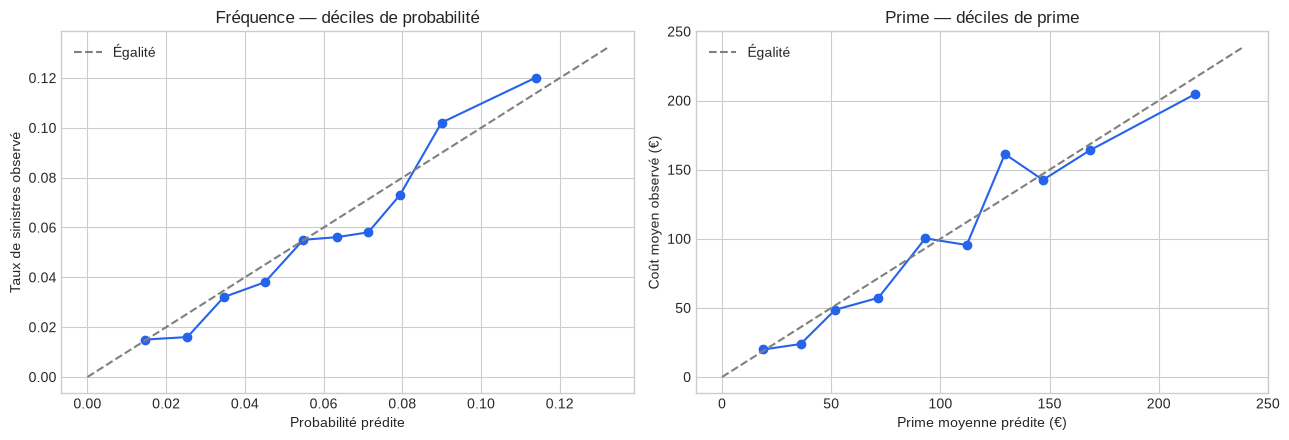

,id,proba_pred,montant_pred,pred,cout_reel,part_erreur_quadratique_pct
2778,14110,0.0798,"1,705.4850",136.0129,"7,068.5400",1.8673
2985,15060,0.0489,"1,771.1520",86.6927,"6,965.1700",1.8383
7735,38825,0.0668,"1,831.4785",122.3579,"6,708.0700",1.6852
7016,35201,0.0667,"1,958.3656",130.6575,"6,484.1700",1.5684
9935,49718,0.0835,"1,684.3676",140.5982,"6,372.0400",1.5088
4920,24556,0.0510,"1,453.2602",74.1764,"6,304.4100",1.5082
1322,6565,0.1153,"1,990.7431",229.5976,"6,443.2300",1.5001
3355,16776,0.0885,"1,925.8426",170.3948,"6,064.0300",1.3496
8412,42134,0.0804,"1,893.1990",152.1650,"6,019.2600",1.3375
8062,40457,0.0816,"1,990.7431",162.3532,"5,915.1000",1.2859


In [9]:
calibration = details_valid.copy()
calibration['decile_frequence'] = pd.qcut(calibration.proba_pred, 10, labels=False, duplicates='drop')
calibration['decile_prime'] = pd.qcut(calibration.pred, 10, labels=False, duplicates='drop')
cal_freq = calibration.groupby('decile_frequence').agg(
    effectif=('id', 'size'), probabilite=('proba_pred', 'mean'),
    taux_observe=('nombre_sinistres', 'mean'))
cal_prime = calibration.groupby('decile_prime').agg(
    effectif=('id', 'size'), prime_predite=('pred', 'mean'), cout_observe=('cout_reel', 'mean'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, x, y, xlabel, ylabel, titre in [
    (axes[0], cal_freq.probabilite, cal_freq.taux_observe,
     'Probabilité prédite', 'Taux de sinistres observé', 'Fréquence — déciles de probabilité'),
    (axes[1], cal_prime.prime_predite, cal_prime.cout_observe,
     'Prime moyenne prédite (€)', 'Coût moyen observé (€)', 'Prime — déciles de prime')]:
    ax.plot(x, y, 'o-', color='#2563eb')
    limite = max(float(x.max()), float(y.max())) * 1.1
    ax.plot([0, limite], [0, limite], '--', color='grey', label='Égalité')
    ax.set(xlabel=xlabel, ylabel=ylabel, title=titre)
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / 'calibration_validation.png', dpi=160, bbox_inches='tight')
plt.show()
cal_freq.to_csv(OUTPUT / 'calibration_frequence.csv')
cal_prime.to_csv(OUTPUT / 'calibration_prime.csv')
erreurs = details_valid.assign(erreur_carree=lambda df: (df.pred - df.cout_reel)**2)
erreurs['part_erreur_quadratique_pct'] = 100 * erreurs.erreur_carree / erreurs.erreur_carree.sum()
display(erreurs.nlargest(10, 'erreur_carree')[
    ['id', 'proba_pred', 'montant_pred', 'pred', 'cout_reel', 'part_erreur_quadratique_pct']])

## 8. Réentraîner pour les 50 000 prospects

Après le diagnostic, nous gardons les deux configurations fixées et réapprenons :

- la fréquence et sa préparation sur **les 50 000 contrats du train**, avec un nouvel encodage hors client pour l'ajustement ;
- le Gamma et sa préparation sur **les 2 917 sinistrés du train**.

Le test Kaggle n'intervient dans aucun apprentissage. Les prédictions finales concernent tous ses prospects. Les paramètres appris sur les 80 % sont remplacés par ceux appris sur tout le train pour cette étape seulement ; ils ne servent pas à recalculer le score de validation.

L'objet `ModelePrime` contient la préparation de fréquence, la logistique et la pipeline Gamma. `predict_details` expose les deux composantes ; `predict` renvoie directement leur produit. Le code de cette classe et de toutes les fonctions est visible dans ce notebook.

In [10]:
class ModelePrime:
    def __init__(self, parametres_frequence, modele_frequence, modele_gravite):
        self.parametres_frequence = parametres_frequence
        self.modele_frequence = modele_frequence
        self.modele_gravite = modele_gravite

    def predict_details(self, frame):
        z = preparer_frequence(frame, self.parametres_frequence)
        colonne = int(np.flatnonzero(self.modele_frequence.classes_ == 1)[0])
        p = self.modele_frequence.predict_proba(z)[:, colonne]
        g = self.modele_gravite.predict(frame)
        if not np.isfinite(p).all() or not np.isfinite(g).all():
            raise ValueError('Prédiction non finie.')
        if not ((p >= 0) & (p <= 1)).all() or not (g > 0).all():
            raise ValueError('Composante hors domaine.')
        return pd.DataFrame({'proba_pred': p, 'montant_pred': g, 'pred': p * g}, index=frame.index)

    def predict(self, frame):
        return self.predict_details(frame)['pred'].to_numpy()

params_finaux, x_complet, audit_final = apprendre_frequence(
    train, train.nombre_sinistres, train.id_client)
frequence_finale = LogisticRegression(C=C_FREQUENCE, max_iter=2000, random_state=SEED)
frequence_finale.fit(x_complet, train.nombre_sinistres)
sinistres_complets = train.loc[train.nombre_sinistres == 1]
gravite_finale = construire_gamma()
gravite_finale.fit(sinistres_complets, sinistres_complets.montant_sinistre)
modele_prime_final = ModelePrime(params_finaux, frequence_finale, gravite_finale)
predictions_test = modele_prime_final.predict_details(test)
predictions_test.insert(0, 'id', test['index'].to_numpy())
audit_final.to_csv(OUTPUT / 'audit_encodage_final.csv', index=False)
predictions_test.to_csv(OUTPUT / 'predictions_prime_test.csv', index=False)
predictions_test[['id', 'proba_pred']].to_csv(OUTPUT / 'predictions_frequence_test.csv', index=False)
predictions_test[['id', 'montant_pred']].to_csv(OUTPUT / 'predictions_gravite_test.csv', index=False)
print('Fréquence finale :', len(train), 'contrats ; gravité finale :', len(sinistres_complets), 'sinistres.')
display(predictions_test.head(10))
display(predictions_test[['proba_pred', 'montant_pred', 'pred']].describe())

Fréquence finale : 50000 contrats ; gravité finale : 2917 sinistres.


,id,proba_pred,montant_pred,pred
0,50000,0.0379,"1,501.2489",56.9642
1,50001,0.0292,"1,332.6152",38.9570
2,50002,0.1033,"1,950.0501",201.3771
3,50003,0.0651,"1,843.6908",119.9561
4,50004,0.0222,"1,507.2929",33.5187
5,50005,0.0178,"1,479.6245",26.3204
6,50006,0.0148,"1,418.6761",21.0247
7,50007,0.0694,"1,789.0089",124.1982
8,50008,0.0742,"1,950.0501",144.7137
9,50009,0.1028,"1,977.5852",203.3320


,proba_pred,montant_pred,pred
count,"50,000.0000","50,000.0000","50,000.0000"
mean,0.0580,"1,676.6091",102.4654
std,0.0303,217.8404,60.7581
min,0.0012,742.8019,1.0397
25%,0.0326,"1,504.5394",48.9490
50%,0.0573,"1,718.8618",100.5994
75%,0.0784,"1,852.6529",144.2657
max,0.2676,"2,001.3723",513.5341


## 9. Construire `submission.csv` et contrôler les identifiants

Le fichier final contient **exactement `index,pred`**, sans colonne supplémentaire pour les numéros de lignes pandas. `pred` est une prime pure, pas une probabilité ni un montant conditionnel.

**Convention confirmée par l'équipe :** nous utilisons la colonne `index` du test comme identifiant `index` (50 000 à 99 999). Le nom de colonne `index` et les valeurs ont été confirmés par l'utilisateur et correspond aux fichiers d'échange précédents. Aucun `sample_submission.csv` n'était fourni dans le dépôt au démarrage.

Si un `sample_submission.csv` est présent dans `Data/` ou à la racine, le code contrôle aussi ses colonnes et ses identifiants, puis respecte son ordre. Le mode `position` reste disponible pour d'autres jeux de données, mais n'est pas utilisé ici. Aucune renumérotation silencieuse n'est effectuée.

In [11]:
MODE_IDENTIFIANT = 'index'  # 50 000 à 99 999, confirmé par l'utilisateur.
IDENTIFIANTS_CONFIRMES = True
if MODE_IDENTIFIANT == 'index':
    ids_soumission = test['index'].to_numpy()
elif MODE_IDENTIFIANT == 'position':
    ids_soumission = np.arange(len(test))
else:
    raise ValueError('MODE_IDENTIFIANT doit être index ou position.')
submission = pd.DataFrame({'index': ids_soumission, 'pred': predictions_test.pred.to_numpy()})
exemples = [p for p in [ROOT / 'Data/sample_submission.csv', ROOT / 'sample_submission.csv'] if p.exists()]
format_officiel_verifie = bool(exemples)
for exemple in exemples:
    attendu = pd.read_csv(exemple)
    if list(attendu.columns) != ['index', 'pred'] or not attendu['index'].is_unique or attendu['index'].isna().any():
        raise ValueError(f'Exemple officiel inattendu : {exemple}')
    if set(attendu['index']) != set(submission['index']):
        raise ValueError('Identifiants différents du sample_submission : vérifier MODE_IDENTIFIANT.')
    submission = attendu[['index']].merge(submission, on='index', validate='one_to_one', sort=False)
assert list(submission.columns) == ['index', 'pred']
assert len(submission) == len(test) and submission['index'].is_unique
assert np.isfinite(submission.pred).all() and submission.pred.ge(0).all()
submission.to_csv(OUTPUT / 'submission.csv', index=False)
lu = pd.read_csv(OUTPUT / 'submission.csv')
assert list(lu.columns) == ['index', 'pred'] and len(lu) == len(test)
np.testing.assert_array_equal(lu['index'], submission['index'])
np.testing.assert_allclose(lu.pred, submission.pred, rtol=1e-12)
print('Fichier produit :', OUTPUT / 'submission.csv')
print('Identifiants :', lu['index'].min(), 'à', lu['index'].max(), '| lignes :', len(lu))
print('Format officiel contrôlé avec sample_submission :', format_officiel_verifie)
display(lu.head())

Fichier produit : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/prime/submission.csv
Identifiants : 50000 à 99999 | lignes : 50000
Format officiel contrôlé avec sample_submission : False


,index,pred
0,50000,56.964216
1,50001,38.957040
2,50002,201.377055
3,50003,119.956087
4,50004,33.518729


## 10. Sauvegarder et vérifier que le résultat est réutilisable

Nous sauvegardons un objet commun et la configuration (choix, versions, empreintes des données et notebooks sources). Un autre processus recharge l'objet, reçoit les colonnes brutes et doit reproduire les mêmes probabilités, montants et primes. Cette vérification évite un modèle qui fonctionnerait uniquement grâce aux variables laissées en mémoire par le notebook.

Nous contrôlons aussi l'assemblage avec un ordre différent des lignes, le refus d'identifiants manquants, l'absence de dépendance aux cibles et le traitement de catégories nouvelles / valeurs manquantes. Seuls les artefacts créés localement par ce projet doivent être rechargés avec `cloudpickle`.

In [12]:
# 1. L'ordre des lignes du fichier de gravité ne doit pas modifier les primes.
join_verifie = assembler_composantes(
    predictions_test[['id', 'proba_pred']],
    predictions_test[['id', 'montant_pred']].sample(frac=1, random_state=SEED))
np.testing.assert_allclose(join_verifie.pred, predictions_test.pred)
try:
    assembler_composantes(predictions_test[['id', 'proba_pred']],
        predictions_test[['id', 'montant_pred']].iloc[1:])
except ValueError:
    pass
else:
    raise AssertionError('Un identifiant manquant aurait dû être refusé.')

# 2. Le Gamma commun reproduit le modèle de gravité retenu précédemment.
ancien_export = ROOT / 'output/gravite/predictions_gravite_test.csv'
if ancien_export.exists():
    ancien = pd.read_csv(ancien_export)
    if len(ancien) != len(predictions_test) or set(ancien.id) != set(predictions_test.id):
        raise ValueError('Export historique de gravité incompatible avec le test actuel.')
    aligne = predictions_test[['id', 'montant_pred']].merge(ancien, on='id', validate='one_to_one')
    np.testing.assert_allclose(aligne.montant_pred_x, aligne.montant_pred_y, rtol=1e-8, atol=1e-6)

# 3. L'objet commun ne lit ni les cibles ni les identifiants comme prédicteurs.
brut = train.iloc[:10]
np.testing.assert_allclose(modele_prime_final.predict(brut),
    modele_prime_final.predict(brut.drop(columns=CIBLES + ['id_client', 'id_vehicule', 'id_contrat', 'index'])))
probe = test.iloc[:3].copy()
for col in ['type_contrat', 'utilisation', 'marque_vehicule', 'modele_vehicule']:
    probe[col] = probe[col].astype(object)
    probe.loc[probe.index[0], col] = '__CATEGORIE_NOUVELLE__'
    probe.loc[probe.index[1], col] = np.nan
probe.loc[probe.index[0], ['anciennete_vehicule', 'poids_vehicule', 'cylindre_vehicule']] = np.nan
assert np.isfinite(modele_prime_final.predict(probe)).all()

# 4. Configuration et objet autonome.
def empreinte(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
configuration = {
    'formule': 'prime = probabilite_sinistre * montant_conditionnel',
    'frequence': {'famille': 'LogisticRegression', 'C': C_FREQUENCE, 'max_iter': 2000,
        'lissage': LISSAGE, 'seuil_rare': SEUIL_RARE, 'encodage': '5 plis groupes par client, prior hors pli',
        'variables_brutes': VARIABLES_FREQUENCE, 'colonnes_encodees': list(params_finaux['colonnes'])},
    'gravite': CONFIG_GAMMA,
    'partition_validation': {'methode': 'GroupShuffleSplit', 'test_size': 0.2, 'seed': SEED,
        'contrats_apprentissage': len(dev), 'contrats_validation': len(valid),
        'sinistres_apprentissage': len(sinistres_dev), 'historique_deja_examinee': True},
    'validation_prime': {k: float(v) for k, v in scores.loc['Logistique_x_Gamma'].items()},
    'entrainement_final': {'contrats_frequence': len(train), 'sinistres_gravite': len(sinistres_complets)},
    'identifiants_soumission': {'colonne': 'index', 'colonnes_csv': ['index', 'pred'], 'mode': MODE_IDENTIFIANT, 'confirmation_utilisateur': IDENTIFIANTS_CONFIRMES,
        'sample_submission_verifie': format_officiel_verifie},
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
        'pandas': pd.__version__, 'sklearn': sklearn.__version__, 'cloudpickle': cloudpickle.__version__},
    'sha256': {str(p.relative_to(ROOT)): empreinte(p) for p in [
        ROOT / 'Data/train.csv', ROOT / 'Data/test.csv',
        ROOT / 'frequence_regression_logisitique.ipynb', ROOT / 'modele_gravite.ipynb']},
}
(OUTPUT / 'configuration_prime.json').write_text(json.dumps(configuration, ensure_ascii=False, indent=2), encoding='utf-8')
artefact = OUTPUT / 'modele_prime_logistique_gamma.pkl'
with artefact.open('wb') as f:
    cloudpickle.dump(modele_prime_final, f)
verification = "import sys,cloudpickle,pandas as pd,numpy as np\nwith open(sys.argv[1],'rb') as f: modele=cloudpickle.load(f)\nx=pd.read_csv(sys.argv[2],dtype={'code_postal':str},nrows=30)\nattendu=pd.read_csv(sys.argv[3],nrows=30)\ncalcule=modele.predict_details(x)\nfor col in ['proba_pred','montant_pred','pred']:\n    np.testing.assert_allclose(calcule[col],attendu[col],rtol=1e-10,atol=1e-7)\nprint('Nouveau processus : probabilités, montants et primes reproduits.')\n"
controle = subprocess.run([sys.executable, '-c', verification, str(artefact),
    str(ROOT / 'Data/test.csv'), str(OUTPUT / 'predictions_prime_test.csv')],
    capture_output=True, text=True, timeout=120, check=True)
print(controle.stdout)
print('Contrôles réussis ; modèle commun sauvegardé :', artefact)

Nouveau processus : probabilités, montants et primes reproduits.

Contrôles réussis ; modèle commun sauvegardé : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/prime/modele_prime_logistique_gamma.pkl


## 11. Résultat final et limites

**Modèle livré : régression logistique (`C=0.1`) × Gamma à trois variables (`alpha=0.1`).** Le choix reste celui des deux équipes ; ce notebook ne sélectionne pas un nouveau modèle en regardant la validation historique.

Le résultat ci-dessous est calculé à partir de l'exécution. Le gain peut être faible ou négatif : la gravité reste difficile à prévoir et les grands sinistres dominent l'erreur quadratique. Une comparaison locale favorable ne garantit pas le classement Kaggle. Le résultat officiel nécessite l'envoi du CSV sur Kaggle et le contrôle de sa convention d'identifiants.

La livraison est un modèle local utilisable pour des prédictions par lot, accompagné de ses prétraitements. Aucun service web n'est déployé et aucun fichier n'est envoyé automatiquement à Kaggle.

In [13]:
retenu = scores.loc['Logistique_x_Gamma']
gain = retenu.gain_RMSE_vs_constante_pct
verdict = 'amélioration' if gain > 0 else 'dégradation' if gain < 0 else 'égalité'
display(Markdown(f"""
**RMSE de la prime sur la validation commune : {retenu.RMSE_EUR:,.2f} €.**

Référence constante : {scores.loc['Prime_constante', 'RMSE_EUR']:,.2f} € ;
{verdict} de **{abs(gain):.2f} %**. MAE : {retenu.MAE_EUR:,.2f} €.

Ces chiffres concernent les **{len(valid):,} contrats de validation**, y compris les coûts nuls.
Le fichier final contient **{len(submission):,} primes**, obtenues en multipliant les deux composantes.

- Notebook : `tarification_frequence_gravite.ipynb`
- Soumission : `output/prime/submission.csv`
- Détail par prospect : `output/prime/predictions_prime_test.csv`
- Modèle commun : `output/prime/modele_prime_logistique_gamma.pkl`
- Configuration : `output/prime/configuration_prime.json`

Colonnes du CSV : **index,pred**. Convention des identifiants : **{MODE_IDENTIFIANT}**.
Identifiants 50 000 à 99 999 : **confirmés par l'utilisateur**.
Comparaison avec un fichier d'exemple local : **{'effectuée' if format_officiel_verifie else 'pas de sample_submission fourni'}**.
"""))


**RMSE de la prime sur la validation commune : 507.65 €.**

Référence constante : 511.47 € ;
amélioration de **0.75 %**. MAE : 190.38 €.

Ces chiffres concernent les **9,987 contrats de validation**, y compris les coûts nuls.
Le fichier final contient **50,000 primes**, obtenues en multipliant les deux composantes.

- Notebook : `tarification_frequence_gravite.ipynb`
- Soumission : `output/prime/submission.csv`
- Détail par prospect : `output/prime/predictions_prime_test.csv`
- Modèle commun : `output/prime/modele_prime_logistique_gamma.pkl`
- Configuration : `output/prime/configuration_prime.json`

Colonnes du CSV : **index,pred**. Convention des identifiants : **index**.
Identifiants 50 000 à 99 999 : **confirmés par l'utilisateur**.
Comparaison avec un fichier d'exemple local : **pas de sample_submission fourni**.


### Références techniques

La méthode de découpage conserve des groupes de clients disjoints, conformément à la [documentation de StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html). Le score en euros utilise [root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html). Les décisions métier et la formule de prime viennent de l'énoncé du projet ; les choix de modèles viennent des deux notebooks de l'équipe.

## 12. Analyse critique du modèle de fréquence de notre partenaire

**Périmètre : la régression logistique `C=0.1` du notebook `frequence_regression_logisitique.ipynb`.** Nous auditons ses choix et reproduisons son résultat sur **son propre découpage**. Nous distinguons ce résultat de celui de l'assemblage, qui utilise un autre découpage et un encodage corrigé.

Pour isoler l'effet de cette correction, nous comparons ensuite les deux recettes sur les mêmes clients, avec le même modèle et les mêmes hyperparamètres. Il s'agit d'un diagnostic historique, pas d'une nouvelle sélection de modèle. Aucun artefact final et aucune soumission ne sont remplacés.

Les fonctions du partenaire sont lues directement dans les cellules de son notebook, dans un espace de variables séparé. Seules les définitions et constantes de préparation sont reprises ; les cellules d'EDA et les anciennes sorties ne sont pas exécutées. Cela évite de réécrire une approximation de son code. Cette annexe s'exécute indépendamment après la création des notebooks du projet.

In [16]:
from pathlib import Path
import ast, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat
from IPython.display import display, Markdown
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)

audit_racines=[Path.cwd(),Path.cwd()/'TD-Tarification-automobile-par-Machine-Learning']
AUDIT_ROOT=next(p for p in audit_racines if (p/'Data/train.csv').exists())
AUDIT_OUTPUT=AUDIT_ROOT/'output/frequence/analyse'
AUDIT_OUTPUT.mkdir(parents=True,exist_ok=True)
audit_source_path=AUDIT_ROOT/'frequence_regression_logisitique.ipynb'
audit_source=nbformat.read(audit_source_path,as_version=4)
audit_commun=nbformat.read(AUDIT_ROOT/'tarification_frequence_gravite.ipynb',as_version=4)
audit_train=pd.read_csv(AUDIT_ROOT/'Data/train.csv',dtype={'code_postal':str})
audit_test=pd.read_csv(AUDIT_ROOT/'Data/test.csv',dtype={'code_postal':str})
audit_exclus=['index','id_client','id_vehicule','id_contrat','nombre_sinistres',
    'montant_sinistre','sex_conducteur1','sex_conducteur2']
audit_x=audit_train.drop(columns=audit_exclus)
audit_y=audit_train.nombre_sinistres
audit_groups=audit_train.id_client
audit_split=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=42)
audit_a,audit_b=next(audit_split.split(audit_x,audit_y,groups=audit_groups))
assert set(audit_groups.iloc[audit_a]).isdisjoint(audit_groups.iloc[audit_b])
audit_raw_dev=audit_train.iloc[audit_a]
audit_raw_valid=audit_train.iloc[audit_b]

def constantes_et_definitions(source,allowed):
    nodes=[]
    for node in ast.parse(source).body:
        if isinstance(node,ast.FunctionDef):
            nodes.append(node)
        elif isinstance(node,ast.Assign):
            noms={n.id for target in node.targets for n in ast.walk(target) if isinstance(n,ast.Name)}
            if noms and noms.issubset(allowed): nodes.append(node)
    return ast.Module(body=nodes,type_ignores=[])

audit_ctx={'np':np,'pd':pd,'SEED':42}
exec(compile(constantes_et_definitions(audit_source.cells[43].source,set()),'nettoyage_partenaire','exec'),audit_ctx)
audit_constantes={'REDONDANTES','A_IMPUTER','QUEUE_LOURDE','CAT_FAIBLE','CAT_FORTE','SEUIL_RARE','LISSAGE'}
exec(compile(constantes_et_definitions(audit_source.cells[45].source,audit_constantes),'preparation_partenaire','exec'),audit_ctx)
audit_xdev=audit_ctx['nettoyer'](audit_x.iloc[audit_a])
audit_xvalid=audit_ctx['nettoyer'](audit_x.iloc[audit_b])
audit_ydev=audit_y.iloc[audit_a]
audit_yvalid=audit_y.iloc[audit_b]
audit_params=audit_ctx['apprendre'](audit_xdev,audit_ydev)
audit_zdev=audit_ctx['preparer'](audit_xdev,audit_params,audit_ydev)
audit_zvalid=audit_ctx['preparer'](audit_xvalid,audit_params)
audit_logistique=LogisticRegression(C=0.1,max_iter=2000)
audit_logistique.fit(audit_zdev,audit_ydev)
audit_pdev=audit_logistique.predict_proba(audit_zdev)[:,1]
audit_pvalid=audit_logistique.predict_proba(audit_zvalid)[:,1]

def audit_mesures(y,p):
    auc=roc_auc_score(y,p)
    return {'log_loss':log_loss(y,p),'Brier':brier_score_loss(y,p),'AUC':auc,'Gini':2*auc-1,
        'sinistres_prevus':np.sum(p),'sinistres_observes':int(np.sum(y))}

audit_scores=pd.DataFrame({
    'Taux moyen — validation':audit_mesures(audit_yvalid,np.full(len(audit_yvalid),audit_ydev.mean())),
    'Logistique originale — apprentissage OOF lignes':audit_mesures(audit_ydev,audit_pdev),
    'Logistique originale — validation clients':audit_mesures(audit_yvalid,audit_pvalid),
}).T
display(audit_scores)
print('Partition du partenaire :',len(audit_a),'contrats pour apprendre ;',len(audit_b),'pour valider.')
print('Colonnes préparées :',audit_zdev.shape[1],'; clients partagés entre apprentissage et validation : 0.')
assert len(audit_a)==39999 and len(audit_b)==10001
assert int(audit_yvalid.sum())==584
# Concordance avec les scores arrondis conservés dans son notebook.
assert abs(log_loss(audit_yvalid,audit_pvalid)-0.2137)<0.00005
audit_scores.to_csv(AUDIT_OUTPUT/'scores_modele_original.csv',index_label='recette')

Partition du partenaire : 39999 contrats pour apprendre ; 10001 pour valider.
Colonnes préparées : 26 ; clients partagés entre apprentissage et validation : 0.


,log_loss,Brier,AUC,Gini,sinistres_prevus,sinistres_observes
Taux moyen — validation,0.222526,0.054984,0.500000,0.000000,583.322908,584.0
Logistique originale — apprentissage OOF lignes,0.213491,0.053982,0.655520,0.311041,2333.455395,2333.0
Logistique originale — validation clients,0.213749,0.054154,0.656749,0.313498,583.220753,584.0


### Ce que son code fait correctement

- La cible est bien la **probabilité d'au moins un sinistre** ; ni le montant ni les identifiants ne deviennent des prédicteurs.
- Il sépare les clients avec `StratifiedGroupKFold` : les contrats d'un même client ne traversent pas l'apprentissage et la validation externe. Dans la recherche d'hyperparamètres, la préparation est réapprise à l'intérieur de chaque pli d'apprentissage.
- Il traite les valeurs manquantes, utilise une imputation hiérarchique par modèle / marque et applique la même préparation à la validation et au test.
- Il regroupe les catégories rares et lisse les taux de sinistres des catégories fines, avec un repli vers le taux moyen pour les modèles de voiture inconnus.
- Il utilise une logistique régularisée et des métriques adaptées aux probabilités : log-loss et Brier, complétées par AUC/Gini et des graphiques de calibration. L'accuracy serait peu informative avec environ 94 % de non-sinistrés.
- Il choisit la logistique via la CV et la simplicité, malgré un boosting un peu meilleur sur la validation historique : il évite ainsi de décider uniquement avec ce dernier jeu.

Ces points constituent une bonne base méthodologique pour le projet.

### Limite concrète : l'encodage « hors pli » interne ne respecte pas les clients

La fonction originale `taux_hors_pli` tire des plis **par ligne** avec `randint`. Un client possédant plusieurs contrats peut alors contribuer au taux qui encode l'un de ses autres contrats. De plus, le prior de lissage `y.mean()` est calculé sur tout l'apprentissage de l'encodage, et contient une petite contribution de la réponse de la ligne encodée.

**Nuance essentielle :** les clients de la validation externe restent exclus de l'apprentissage, y compris des taux appris. Ce problème ne signifie donc pas que les cibles de validation entrent directement dans les prédictions. Il concerne les représentations des lignes d'apprentissage et rend la comparaison train/validation moins probante. Le prior global introduit une fuite faible mais évitable ; il ne faut pas lui attribuer à lui seul la totalité des écarts de performance.

L'assemblage a corrigé ces deux règles. La comparaison ci-dessous conserve **le découpage original du partenaire** pour isoler la correction ; elle ne réutilise pas les scores de notre autre partition.

In [17]:
audit_plis_lignes=np.random.RandomState(42).randint(0,5,len(audit_xdev))
audit_plis_clients=pd.DataFrame({'client':audit_groups.iloc[audit_a].to_numpy(),'pli':audit_plis_lignes})
audit_nplis=audit_plis_clients.groupby('client').pli.nunique()
audit_clients_partages=set(audit_nplis.index[audit_nplis>1])
audit_lignes_partagees=int(audit_plis_clients.client.isin(audit_clients_partages).sum())
print('Clients d’apprentissage présents dans plusieurs plis internes :',len(audit_clients_partages))
print('Contrats dont un autre contrat du même client est dans un autre pli :',audit_lignes_partagees)

# Reprendre exactement la recette corrigée de l'assemblage dans un espace distinct.
audit_corr={'np':np,'pd':pd,'SEED':42,'StratifiedGroupKFold':StratifiedGroupKFold,
    'VARIABLES_FREQUENCE':list(audit_x.columns)}
exec(compile(audit_commun.cells[8].source,'preparation_corrigee_assemblage','exec'),audit_corr)
audit_params_corr,audit_zdev_corr,audit_folds_corr=audit_corr['apprendre_frequence'](
    audit_raw_dev,audit_ydev,audit_groups.iloc[audit_a])
audit_zvalid_corr=audit_corr['preparer_frequence'](audit_raw_valid,audit_params_corr)
audit_logistique_corr=LogisticRegression(C=0.1,max_iter=2000)
audit_logistique_corr.fit(audit_zdev_corr,audit_ydev)
audit_pcorr=audit_logistique_corr.predict_proba(audit_zvalid_corr)[:,1]
audit_comparaison=pd.DataFrame({
    'Recette originale':audit_mesures(audit_yvalid,audit_pvalid),
    'Recette corrigée, mêmes clients':audit_mesures(audit_yvalid,audit_pcorr),
}).T
display(audit_comparaison)
display(audit_folds_corr)
audit_comparaison.to_csv(AUDIT_OUTPUT/'comparaison_encodages_memes_clients.csv',index_label='recette')
audit_folds_corr.to_csv(AUDIT_OUTPUT/'audit_plis_clients_corriges.csv',index=False)

Clients d’apprentissage présents dans plusieurs plis internes : 2540
Contrats dont un autre contrat du même client est dans un autre pli : 5322


,log_loss,Brier,AUC,Gini,sinistres_prevus,sinistres_observes
Recette originale,0.213749,0.054154,0.656749,0.313498,583.220753,584.0
"Recette corrigée, mêmes clients",0.213834,0.054163,0.655911,0.311823,583.048494,584.0


,pli,contrats_apprentissage,contrats_encodés,clients_communs,prior_autres_plis
0,1,31999,8000,0,0.058314
1,2,31998,8001,0,0.058316
2,3,32000,7999,0,0.058344
3,4,31999,8000,0,0.058314
4,5,32000,7999,0,0.058344


### La correction améliore-t-elle réellement le score ?

Nous calculons un intervalle bootstrap apparié sur l'écart de **log-loss de validation** : les clients sont rééchantillonnés avec tous leurs contrats, et les deux modèles utilisent exactement les mêmes tirages. Un gain positif favorise la recette corrigée. Si l'intervalle contient zéro, nous ne revendiquons pas d'amélioration prédictive démontrée par cette validation.

Corriger la séparation des clients reste une amélioration méthodologique même si le score change peu. Ce bootstrap est conditionnel aux deux modèles déjà ajustés : il n'inclut pas la sélection ou le réapprentissage et n'efface pas l'exploration historique.

Gain observé de log-loss (originale − corrigée) : -0.0000853
Intervalle bootstrap conditionnel 95 % : [-0.0001913 ; 0.0000259]


,effectif,sinistres,probabilite,taux_observe,ecart_points_pct
decile,,,,,
0,1001,10,0.014235,0.00999,0.424514
1,1000,22,0.024678,0.02200,0.267775
2,1000,30,0.033530,0.03000,0.353006
3,1000,48,0.043147,0.04800,-0.485322
4,1000,55,0.053005,0.05500,-0.199476
5,1000,63,0.062170,0.06300,-0.083047
6,1000,64,0.070447,0.06400,0.644725
7,1000,92,0.078934,0.09200,-1.306633
8,1000,98,0.089792,0.09800,-0.820759


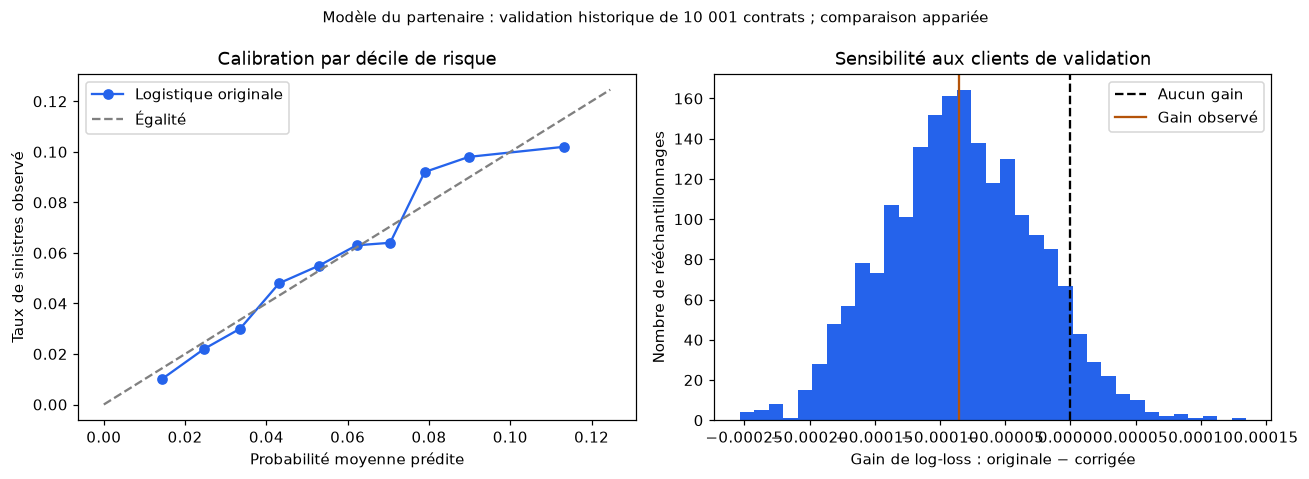

In [18]:
audit_yy=audit_yvalid.to_numpy()
def audit_log_losses(y,p):
    p=np.clip(p,1e-15,1-1e-15)
    return -(y*np.log(p)+(1-y)*np.log1p(-p))
audit_losses=pd.DataFrame({'client':audit_groups.iloc[audit_b].to_numpy(),'n':1,
    'originale':audit_log_losses(audit_yy,audit_pvalid),
    'corrigee':audit_log_losses(audit_yy,audit_pcorr)})
audit_blocks=audit_losses.groupby('client',sort=False).sum()
audit_rng=np.random.default_rng(20261009)
audit_gains=[]
audit_delta=(audit_blocks.originale-audit_blocks.corrigee).to_numpy()
audit_counts=audit_blocks.n.to_numpy()
for batch in range(20):
    draws=audit_rng.integers(0,len(audit_blocks),size=(100,len(audit_blocks)))
    audit_gains.extend((audit_delta[draws].sum(axis=1)/audit_counts[draws].sum(axis=1)).tolist())
audit_gain=log_loss(audit_yvalid,audit_pvalid)-log_loss(audit_yvalid,audit_pcorr)
audit_ic=np.quantile(audit_gains,[.025,.975])
print(f'Gain observé de log-loss (originale − corrigée) : {audit_gain:.7f}')
print(f'Intervalle bootstrap conditionnel 95 % : [{audit_ic[0]:.7f} ; {audit_ic[1]:.7f}]')
audit_calibration=pd.DataFrame({'y':audit_yy,'p':audit_pvalid})
audit_calibration['decile']=pd.qcut(audit_calibration.p,10,labels=False,duplicates='drop')
audit_cal=audit_calibration.groupby('decile').agg(effectif=('y','size'),
    sinistres=('y','sum'),probabilite=('p','mean'),taux_observe=('y','mean'))
audit_cal['ecart_points_pct']=100*(audit_cal.probabilite-audit_cal.taux_observe)
display(audit_cal)
audit_cal.to_csv(AUDIT_OUTPUT/'calibration_originale.csv')
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
axes[0].plot(audit_cal.probabilite,audit_cal.taux_observe,'o-',color='#2563eb',label='Logistique originale')
limite=max(audit_cal.probabilite.max(),audit_cal.taux_observe.max())*1.1
axes[0].plot([0,limite],[0,limite],'--',color='grey',label='Égalité')
axes[0].set(xlabel='Probabilité moyenne prédite',ylabel='Taux de sinistres observé',title='Calibration par décile de risque')
axes[0].legend()
axes[1].hist(audit_gains,bins=35,color='#2563eb')
axes[1].axvline(0,color='black',linestyle='--',label='Aucun gain')
axes[1].axvline(audit_gain,color='#b45309',label='Gain observé')
axes[1].set(xlabel='Gain de log-loss : originale − corrigée',ylabel='Nombre de rééchantillonnages',title='Sensibilité aux clients de validation')
axes[1].legend()
fig.suptitle('Modèle du partenaire : validation historique de 10 001 contrats ; comparaison appariée',fontsize=10)
fig.tight_layout()
fig.savefig(AUDIT_OUTPUT/'analyse_frequence.png',dpi=160,bbox_inches='tight')
display(fig)
plt.close(fig)

### Les autres faiblesses de son modèle

**Pouvoir prédictif modéré.** Le modèle bat le taux moyen sur log-loss et Brier, mais son AUC reste autour de 0,66 sur sa validation. Cela signifie un classement utile, loin d'une identification certaine des futurs sinistrés. Son Gini est seulement une transformation de l'AUC, pas une seconde preuve indépendante.

**Forme trop rigide possible.** La logistique est additive dans le log des odds. Le bonus, l'âge ou l'ancienneté peuvent avoir des effets courbes, et contrat × usage peut compter. Le log1p de certaines variables n'offre pas à lui seul cette souplesse. C'est une hypothèse de sous-apprentissage à tester, pas une conclusion démontrée.

**Variables retirées trop vite.** Corrélation entre prix, vitesse et puissance ne signifie pas information identique. Avec une régularisation, on peut comparer l'ajout du prix et vérifier son gain. Les paramètres du prétraitement (seuil rare 50, lissage 100, transformations) n'ont pas été optimisés avec le modèle. La recherche de `C` montre des scores presque égaux pour 0,1 / 1 / 10 : affiner encore `C` ne semble pas la meilleure priorité.

**Calibration à mieux étayer.** Environ 583 sinistres prédits pour 584 observés est rassurant au niveau du portefeuille, mais peut masquer des erreurs entre segments. Les scores train/validation proches sont rassurants aussi, mais ne prouvent pas une absence de sur-apprentissage. La phrase « écarts plus petits que l'écart-type des plis donc non significatifs » n'est pas un test statistique valide : il faut une comparaison appariée. Le notebook indique une CV boosting proche de 0,2148 contre 0,2142 pour la logistique, mais la sortie de sa recherche boosting n'est pas conservée ; il faudrait enregistrer la grille et les scores pour rendre cette comparaison vérifiable.

**Critère final différent.** La log-loss évalue une probabilité ; Kaggle évalue le coût `p × g`. La meilleure fréquence en log-loss n'est pas obligatoirement la meilleure composante de prime une fois Gamma fixé. Il faut garder ces métriques de fréquence et comparer les paires sur la RMSE des primes, dans les plis d'apprentissage prévus.

**Questions de données.** L'unité de `duree_contrat` (valeurs 1 à 41) et la période d'observation des sinistres doivent être clarifiées avant d'interpréter une fréquence annuelle. Il n'y a pas de validation temporelle avec les données actuelles. Le département par préfixe à deux caractères convient aux valeurs métropolitaines observées, dont 2A/2B ; des codes d'outre-mer demanderaient un traitement différent.

### Ce que je changerais, dans cet ordre

1. **Synchroniser son notebook avec l'encodage corrigé de l'assemblage.** Conserver la partition par client à tous les niveaux et calculer le prior uniquement dans les autres plis. Garder le modèle `C=0.1` comme référence. Ne pas présenter cette correction comme un gain de score certain si le diagnostic ci-dessus ne l'établit pas.
2. **Tester peu de transformations métier.** D'abord des splines du bonus, de l'âge du conducteur et de l'ancienneté du véhicule ; ensuite une interaction contrat × usage et l'ajout du prix. Comparer sur les mêmes plis clients, avec préparation réapprise dans chaque pli. Ces essais peuvent enrichir la logistique sans changer de famille.
3. **Choisir les améliorations avec la prime complète.** Dans la CV commune, vérifier log-loss, Brier, calibration et RMSE de `p × Gamma`. Si des réglages sont recherchés, les choisir dans les plis internes et évaluer dans les plis externes. Ne pas utiliser les résultats historiques répétés comme une nouvelle validation indépendante.
4. **Tester la calibration seulement à partir de prédictions hors pli.** Une calibration sigmoïde est une candidate ; elle n'est pas automatiquement utile. Ne pas multiplier toutes les probabilités par `584 / 583` à partir de la validation pour annoncer ensuite un meilleur score sur cette même validation.
5. **Comparer un modèle plus souple avec une préparation adaptée.** Le boosting a été testé sur des entrées préparées pour la logistique. Un essai avec ses propres variables et traitements est plus pertinent que d'augmenter arbitrairement sa profondeur. Enregistrer ses paramètres et scores CV ; adopter la complexité seulement si le gain de prime est stable.

**Ce que je garderais :** la logistique comme baseline forte, la régularisation, la séparation des clients, l'imputation hiérarchique, le lissage et les métriques probabilistes. Je n'introduirais ni seuil à 0,5 pour calculer la prime, ni suréchantillonnage / pondération automatique des classes sans vérifier l'effet sur la calibration.

In [19]:
audit_original=audit_scores.loc['Logistique originale — validation clients']
audit_baseline=audit_scores.loc['Taux moyen — validation']
audit_resume={
    'modele_audite':'LogisticRegression C=0.1 du notebook du partenaire',
    'source':audit_source_path.name,
    'sha256_source':hashlib.sha256(audit_source_path.read_bytes()).hexdigest(),
    'contrats_apprentissage':len(audit_a),'contrats_validation':len(audit_b),
    'log_loss_originale':float(audit_original.log_loss),
    'log_loss_taux_moyen':float(audit_baseline.log_loss),
    'gain_log_loss_vs_taux_moyen_pct':float(100*(1-audit_original.log_loss/audit_baseline.log_loss)),
    'auc_originale':float(audit_original.AUC),
    'sinistres_prevus':float(audit_original.sinistres_prevus),
    'sinistres_observes':int(audit_original.sinistres_observes),
    'clients_partages_entre_plis_encodage_original':len(audit_clients_partages),
    'contrats_concernes_encodage':audit_lignes_partagees,
    'log_loss_corrigee_memes_clients':float(log_loss(audit_yvalid,audit_pcorr)),
    'gain_log_loss_correction':float(audit_gain),
    'intervalle_bootstrap_95_gain_correction':[float(audit_ic[0]),float(audit_ic[1])],
    'limite':'validation historique ; bootstrap conditionnel, sans réapprentissage ni nouvelle sélection',
}
(AUDIT_OUTPUT/'resume_analyse_frequence.json').write_text(json.dumps(audit_resume,ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown(f"""
**Verdict sur le modèle de ton ami : une bonne référence explicable, avec un gain réel dans son diagnostic historique, mais un classement des risques modéré.**

- Log-loss : **{audit_original.log_loss:.5f}**, contre **{audit_baseline.log_loss:.5f}** pour le taux moyen (**{audit_resume['gain_log_loss_vs_taux_moyen_pct']:.2f} %** de réduction).
- AUC : **{audit_original.AUC:.3f}** ; total de sinistres prévus : **{audit_original.sinistres_prevus:.1f}**, contre **{int(audit_original.sinistres_observes)}** observés.
- Correction de l'encodage, à clients identiques : gain de log-loss **{audit_gain:.7f}**, intervalle bootstrap conditionnel **[{audit_ic[0]:.7f} ; {audit_ic[1]:.7f}]**.

La première amélioration est de rendre son encodage entièrement cohérent avec la règle par client. La prochaine piste prédictive est d'assouplir quelques effets métier et d'évaluer la prime complète, plutôt que d'affiner sans fin la valeur de `C`.
"""))


**Verdict sur le modèle de ton ami : une bonne référence explicable, avec un gain réel dans son diagnostic historique, mais un classement des risques modéré.**

- Log-loss : **0.21375**, contre **0.22253** pour le taux moyen (**3.94 %** de réduction).
- AUC : **0.657** ; total de sinistres prévus : **583.2**, contre **584** observés.
- Correction de l'encodage, à clients identiques : gain de log-loss **-0.0000853**, intervalle bootstrap conditionnel **[-0.0001913 ; 0.0000259]**.

La première amélioration est de rendre son encodage entièrement cohérent avec la règle par client. La prochaine piste prédictive est d'assouplir quelques effets métier et d'évaluer la prime complète, plutôt que d'affiner sans fin la valeur de `C`.


Références : la documentation scikit-learn décrit l'objectif de la [régression logistique](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression), la nécessité de [cross-fitting pour un encodage cible](https://scikit-learn.org/stable/modules/preprocessing.html#target-encoder) et les limites des [mesures de calibration](https://scikit-learn.org/stable/modules/calibration.html). Les chiffres ci-dessus viennent de la reproduction du code du partenaire sur nos données, avec sa partition d'origine.